## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, PowerTransformer, label_binarize
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import BorderlineSMOTE, SMOTE
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.utils import resample
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, average_precision_score, ConfusionMatrixDisplay, classification_report, balanced_accuracy_score, roc_curve, precision_recall_curve, brier_score_loss, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, StratifiedKFold, RandomizedSearchCV
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from dataclasses import dataclass, field
from scipy.optimize import minimize
from collections import Counter
from scipy.special import expit
from scipy.stats import skew
from shapely.geometry import Point
import shap
import time
import gc
import geopandas as gpd
import contextily as ctx
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBClassifier, plot_importance
import warnings
import matplotlib.ticker as mticker
import pyproj
from pyproj import Transformer

warnings.filterwarnings('ignore')

#### Data Preparation

In [4]:
df = pd.read_csv("finalest_dataset.csv") # Load raw dataset
sumatra = df.loc[(95 <= df['longitude']) & (df['longitude'] <= 108) & (-6 <= df['latitude']) & (df['latitude'] <= 6)] # Filter for Sumatra region
sumatra['period_start'] = pd.to_datetime(sumatra['period_start'])
# sort chronologically
sumatra = sumatra.sort_values('period_start')
sumatra

,FF_mean,RH_mean,RR_sum,TAVG_mean,period_start,longitude,latitude,Aktivitas Manusia,Perhutanan,Perkebunan,Perladangan,Persemakan,fire_presence
6041554,1.952946,84.391661,116.108944,26.334077,2023-01-01,106.040052,-3.234905,2159.704913,0,0,0,1,0
6019789,0.897191,87.408183,176.996063,25.739375,2023-01-01,103.499514,-1.126799,403.763784,0,0,1,0,0
6019790,0.897191,87.408183,176.996063,25.739375,2023-01-01,103.499514,-1.135808,1329.286414,0,0,1,0,0
6019791,0.897191,87.408183,176.996063,25.739375,2023-01-01,103.499514,-1.144817,1851.994140,0,0,1,0,0
6019792,0.873230,87.003470,183.058353,25.708520,2023-01-01,103.499514,-1.153826,1711.351380,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1890019,1.005427,89.757042,4.667724,25.636106,2024-12-29,102.337353,0.395722,13465.822577,1,0,0,0,0
1890020,1.005427,89.757042,5.301565,25.636106,2024-12-29,102.337353,0.386713,12630.857430,1,0,0,0,0
1890021,1.005427,89.757042,5.301565,25.636106,2024-12-29,102.337353,0.377704,11820.889418,1,0,0,0,0
1890008,1.127935,89.734922,0.000000,25.674070,2024-12-29,102.337353,0.494821,14237.742981,0,0,0,0,0


In [ ]:
# Make temporal features
sumatra['year'] = sumatra['period_start'].dt.year
sumatra['month'] = sumatra['period_start'].dt.month

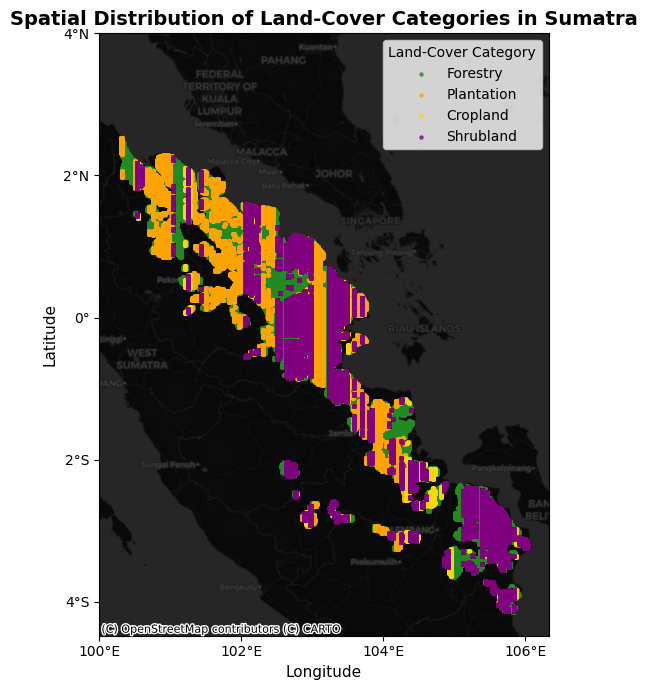

In [ ]:
# Convert to GeoDataFrame
plot_df = sumatra.copy()
landcover_cols = ["Perhutanan", "Perkebunan", "Perladangan", "Persemakan"]
plot_df["Land_Cover"] = (plot_df[landcover_cols].idxmax(axis=1))
gdf = gpd.GeoDataFrame(plot_df, geometry=gpd.points_from_xy(plot_df["longitude"], plot_df["latitude"]), crs="EPSG:4326")
# Plotting Land Cover Distribution
fig, ax = plt.subplots(figsize=(9, 7))
colors = {"Perhutanan": "forestgreen", "Perkebunan": "orange", "Perladangan": "gold", "Persemakan": "purple"}
english_labels = {"Perhutanan": "Forestry", "Perkebunan": "Plantation", "Perladangan": "Cropland", "Persemakan": "Shrubland"}
for category, color in colors.items():
    subset = gdf[gdf["Land_Cover"] == category]
    subset.plot(ax=ax, color=color, alpha=0.70, markersize=5, label=english_labels[category])
ctx.add_basemap(ax, crs=gdf.crs, source=ctx.providers.CartoDB.DarkMatter)
lon_ticks = [100, 102, 104, 106] # Longitude ticks
ax.set_xticks(lon_ticks)
ax.set_xticklabels([f"{lon}°E" for lon in lon_ticks])
lat_ticks = [-4, -2, 0, 2, 4] # Latitude ticks
ax.set_yticks(lat_ticks)
ax.set_yticklabels(["0°" if lat == 0 else (f"{abs(lat)}°S" if lat < 0 else f"{lat}°N") for lat in lat_ticks])
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.set_title("Spatial Distribution of Land-Cover Categories in Sumatra", fontsize=14, fontweight="bold")
ax.legend(title="Land-Cover Category", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

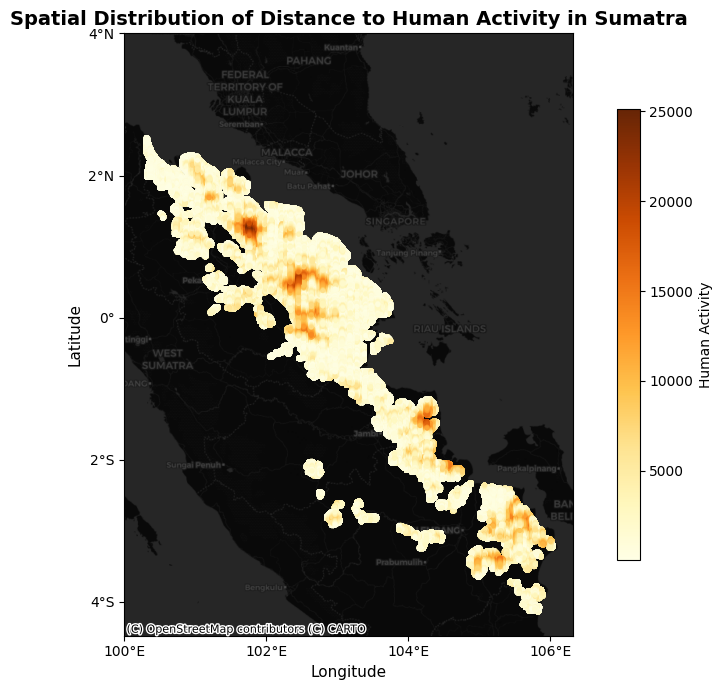

In [ ]:
# Convert to GeoDataFrame
plot_df = sumatra.copy()
gdf = gpd.GeoDataFrame(plot_df, geometry=gpd.points_from_xy(plot_df["longitude"], plot_df["latitude"]), crs="EPSG:4326")
gdf_plot = gdf.to_crs(epsg=3857)
# Plot Distribution of Distance to Human Activity
fig, ax = plt.subplots(figsize=(9, 7))
gdf_plot.plot(ax=ax, column="Aktivitas Manusia", cmap="YlOrBr", markersize=7, alpha=0.85, legend=True, legend_kwds={"label": "Human Activity","orientation": "vertical","shrink": 0.75})
ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter)
lon_ticks = [100, 102, 104, 106]
transformer = pyproj.Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
x_ticks = [transformer.transform(lon, 0)[0] for lon in lon_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels([f"{lon}°E" for lon in lon_ticks])
lat_ticks = [-4, -2, 0, 2, 4]
y_ticks = [transformer.transform(0, lat)[1] for lat in lat_ticks]
ax.set_yticks(y_ticks)
ax.set_yticklabels(["0°" if lat == 0 else (f"{abs(lat)}°S" if lat < 0 else f"{lat}°N") for lat in lat_ticks])
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.set_title("Spatial Distribution of Distance to Human Activity in Sumatra", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

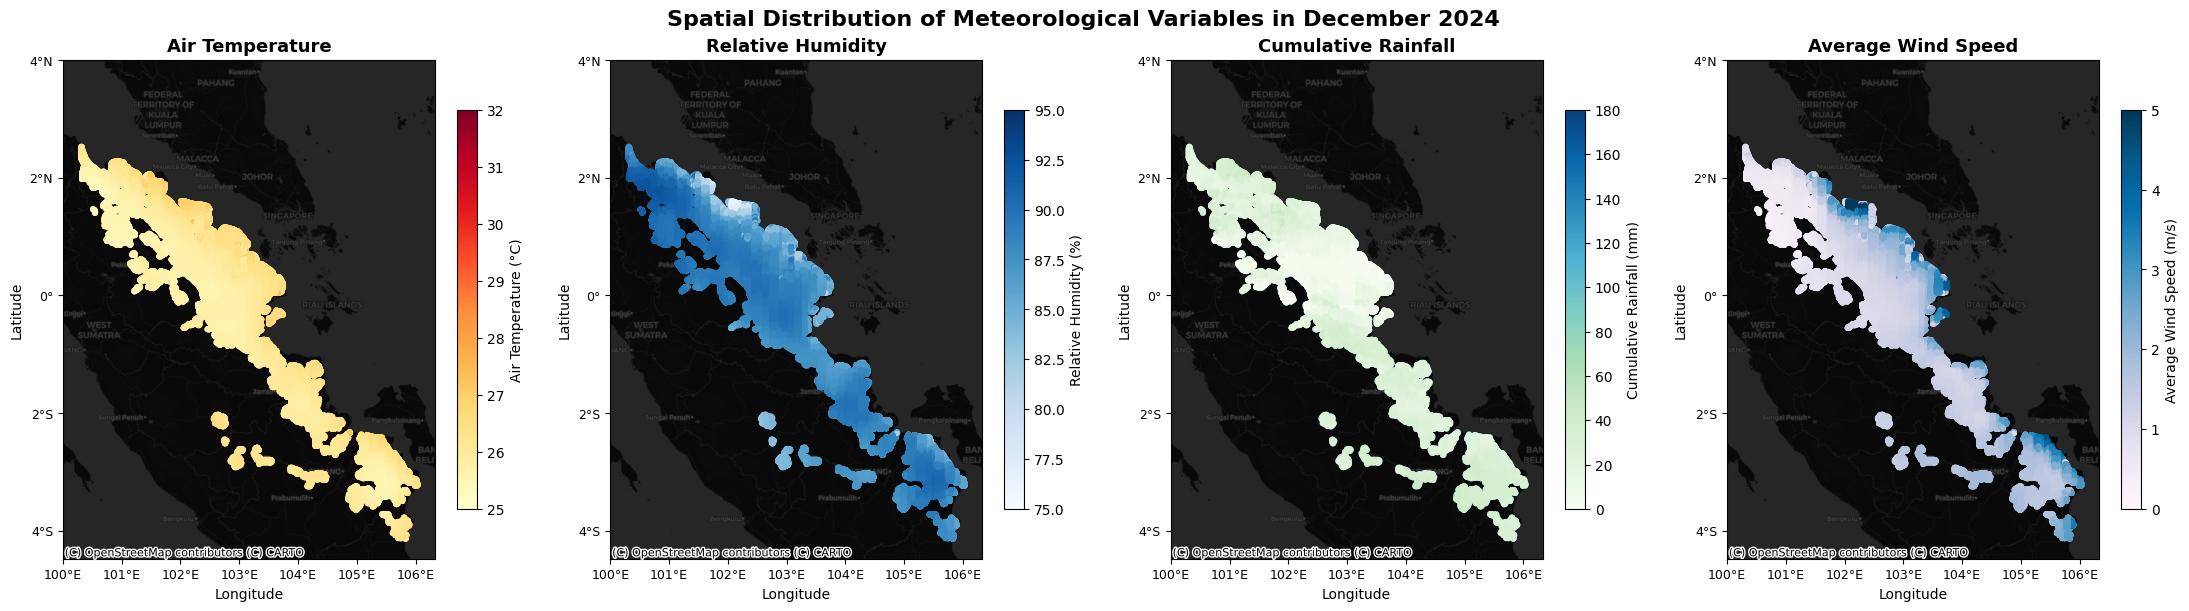

In [ ]:
# Plotting Meteorological Variables
sumatra["date"] = pd.to_datetime(sumatra["period_start"])
filter_2024 = sumatra[(sumatra["date"].dt.year == 2024) & (sumatra["date"].dt.month == 12)].copy()
# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(filter_2024, geometry=gpd.points_from_xy(filter_2024["longitude"], filter_2024["latitude"]), crs="EPSG:4326")
gdf_web = gdf.to_crs(epsg=3857)
# Split into four individual variables
variables = {"TAVG_mean": {"title": "Air Temperature","label": "Air Temperature (°C)","cmap": "YlOrRd"},
             "RH_mean": {"title": "Relative Humidity","label": "Relative Humidity (%)","cmap": "Blues"},
             "RR_sum": {"title": "Cumulative Rainfall","label": "Cumulative Rainfall (mm)","cmap": "GnBu"},
             "FF_mean": {"title": "Average Wind Speed","label": "Average Wind Speed (m/s)","cmap": "PuBu"}
}
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857",always_xy=True)
# Longitude
lon_ticks = [100, 101, 102, 103, 104, 105, 106]
# Latitude
lat_ticks = [-4, -2, 0, 2, 4]
# Convert coordinates into Web Mercator
lon_x = [transformer.transform(lon, 0)[0] for lon in lon_ticks]
lat_y = [transformer.transform(0, lat)[1] for lat in lat_ticks]
# Heatmap 
vmax_values = {"TAVG_mean": 32, "RH_mean": 95, "RR_sum": 180, "FF_mean": 5}
vmin_values = {"TAVG_mean": 25, "RH_mean": 75, "RR_sum": 0, "FF_mean": 0}
fig, axes = plt.subplots(1, 4, figsize=(22, 6), constrained_layout=True)
for ax, (column, config) in zip(axes, variables.items()):
    gdf_web.plot(ax=ax, column=column, cmap=config["cmap"], markersize=8, alpha=0.8, legend=True, vmin=vmin_values[column], vmax=vmax_values[column],legend_kwds={"label": config["label"], "shrink": 0.80})
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter)
    ax.set_xticks(lon_x)
    ax.set_xticklabels([f"{lon}°E" for lon in lon_ticks], fontsize=9)
    ax.set_yticks(lat_y)
    ax.set_yticklabels([f"{abs(lat)}°S" if lat < 0 else f"{lat}°N" for lat in lat_ticks], fontsize=9)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.set_title(config["title"], fontsize=13, fontweight="bold")
fig.suptitle("Spatial Distribution of Meteorological Variables in December 2024", fontsize=16,fontweight="bold")
# Plotting
plt.show()

### Plot Spatial Plot Fire Presence in Sumatra

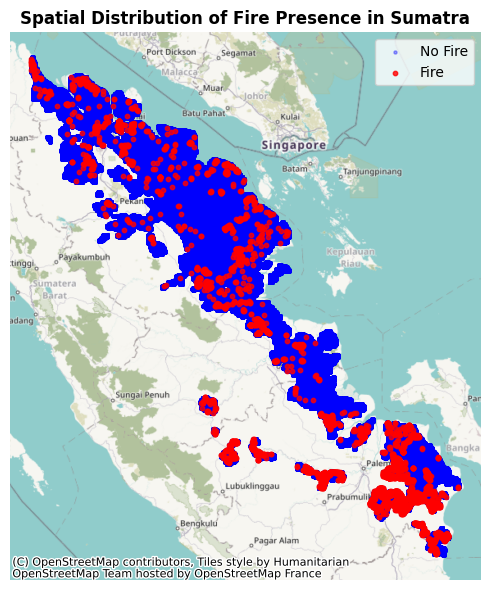

In [ ]:
# Plot Spatial Distribution of Fire Presence in Sumatra
gdf = gpd.GeoDataFrame(sumatra, geometry=gpd.points_from_xy(sumatra['longitude'], sumatra['latitude']), crs="EPSG:4326").to_crs(epsg=3857)
gdf0 = gdf[gdf['fire_presence'] == 0] # No Fire
gdf1 = gdf[gdf['fire_presence'] == 1] # Fire
fig, ax = plt.subplots(figsize=(6, 6))
gdf0.plot(ax=ax,color="blue",alpha=0.35,markersize=5,label="No Fire")
gdf1.plot(ax=ax,color="red",alpha=0.8,markersize=10,label="Fire")
ctx.add_basemap(ax)
ax.set_title("Spatial Distribution of Fire Presence in Sumatra",fontweight='bold')
ax.legend()
ax.axis("off")
plt.tight_layout()
plt.show()

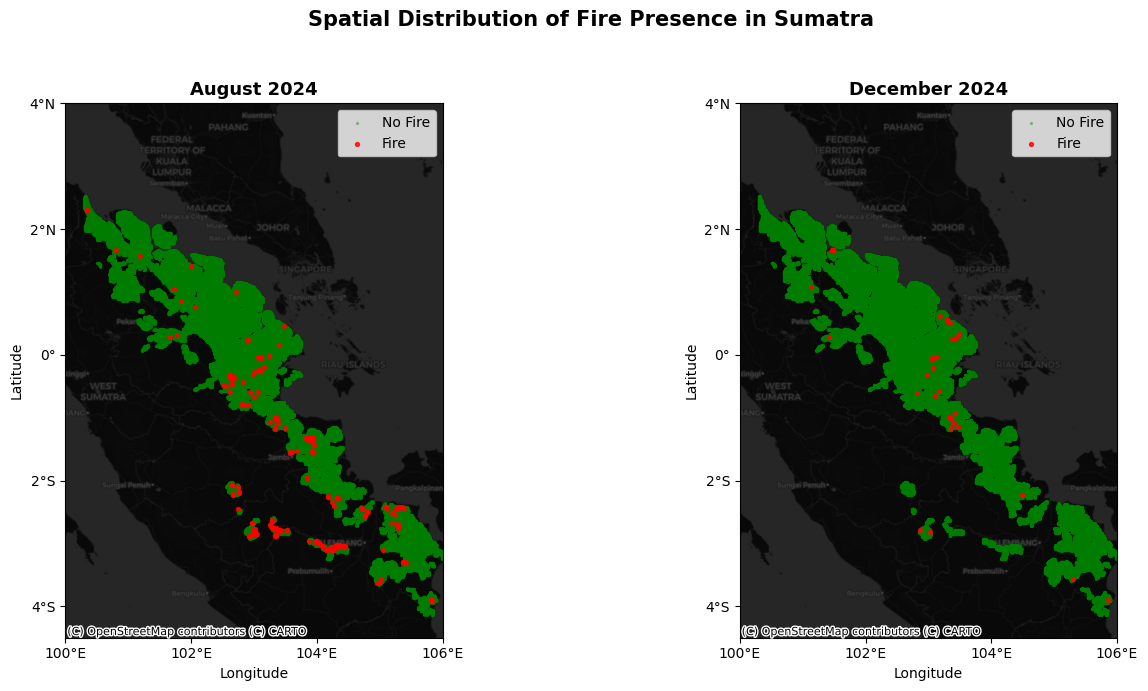

In [ ]:
# Plot fire presence for dry and wet seasons
gdf = gpd.GeoDataFrame(sumatra.copy(), geometry=gpd.points_from_xy(sumatra["longitude"], sumatra["latitude"]), crs="EPSG:4326")
gdf["date"] = pd.to_datetime(gdf["period_start"])
gdf_aug = gdf[(gdf["date"].dt.year == 2024) & (gdf["date"].dt.month == 8)].copy() # Dry season
gdf_dec = gdf[(gdf["date"].dt.year == 2024) & (gdf["date"].dt.month == 12)].copy() # Wet season
# Dry season
aug_no_fire = gdf_aug[gdf_aug["fire_presence"] == 0]
aug_fire = gdf_aug[gdf_aug["fire_presence"] == 1]
# Wet season
dec_no_fire = gdf_dec[gdf_dec["fire_presence"] == 0]
dec_fire = gdf_dec[gdf_dec["fire_presence"] == 1]
# Plotting fire distribution between dry and wet seasons
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
aug_no_fire.plot(ax=axes[0], color="green", alpha=0.30, markersize=2, label="No Fire")
aug_fire.plot(ax=axes[0], color="red", alpha=0.80, markersize=8, label="Fire")
ctx.add_basemap(axes[0], crs=gdf.crs, source=ctx.providers.CartoDB.DarkMatter)
axes[0].set_title("August 2024", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
dec_no_fire.plot(ax=axes[1], color="green", alpha=0.30, markersize=2, label="No Fire")
dec_fire.plot(ax=axes[1], color="red", alpha=0.80, markersize=8, label="Fire")
ctx.add_basemap(axes[1], crs=gdf.crs, source=ctx.providers.CartoDB.DarkMatter)
axes[1].set_title("December 2024", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
for ax in axes:
    ax.set_xlim(100, 106)
    ax.set_ylim(-4.5, 4)
# Set longitude and latitude ticks and labels
lon_ticks = [100, 102, 104, 106]
lat_ticks = [-4, -2, 0, 2, 4]
for ax in axes:
    ax.set_xticks(lon_ticks)
    ax.set_xticklabels([f"{lon}°E" for lon in lon_ticks])
    ax.set_yticks(lat_ticks)
    ax.set_yticklabels([f"{abs(lat)}°S" if lat < 0 else f"{lat}°N" for lat in lat_ticks])
axes[0].legend(loc="upper right", frameon=True)
axes[1].legend(loc="upper right", frameon=True)
fig.suptitle("Spatial Distribution of Fire Presence in Sumatra", fontsize=15, fontweight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#### Setting Features and Target

In [ ]:
features = ['FF_mean', 'RH_mean', 'RR_sum', 'TAVG_mean', 'Aktivitas Manusia', 'longitude', 'latitude', 'Perhutanan', 'Perkebunan', 'Perladangan', 'Persemakan', 'month']
# Training Data
train_features = ['FF_mean', 'RH_mean', 'RR_sum', 'TAVG_mean', 'Aktivitas Manusia', 'Perhutanan', 'Perkebunan', 'Perladangan', 'Persemakan']
# Target
target = 'fire_presence'

#### Define Auto Shifted Log Transformation

In [ ]:
def find_best_eta(x, skew_type='positive'):
    """ Find the optimal ASLT shift parameter eta using ONLY the training data."""
    etas = np.linspace(0.01, 10.0, 100)
    best_eta = None
    best_score = np.inf
    x_min = np.min(x)
    x_max = np.max(x)
    for eta in etas:
        if skew_type == 'positive':
            xt = np.log(x - x_min + eta)
        else:
            xt = -np.log(x_max - x + eta)
        score = abs(skew(xt))
        if score < best_score:
            best_score = score
            best_eta = eta
    return best_eta


def fit_auto_shifted_log(df, columns):
    """
    Fit ASLT parameters using training data only.
    Returns:
        df_transformed : transformed training data
        transform_info : fitted ASLT parameters
    """
    df_transformed = df.copy()
    transform_info = {}
    for col in columns:
        x = df[col].astype(float).values
        # Original training skewness
        sk = skew(x)
        # Transformation direction determined from TRAIN
        skew_type = 'positive' if sk > 0 else 'negative'
        # Training extrema
        train_min = np.min(x)
        train_max = np.max(x)
        # Optimize eta using train only
        eta = find_best_eta(x, skew_type)
        # Apply transformation to train
        if skew_type == 'positive':
            x_trans = np.log(x - train_min + eta)
        else:
            x_trans = -np.log(train_max - x + eta)
        df_transformed[col] = x_trans
        # Save all parameters required
        transform_info[col] = {
            'original_skewness': sk,
            'eta': eta,
            'type': skew_type,
            'train_min': train_min,
            'train_max': train_max
        }
    return df_transformed, transform_info

def apply_auto_shifted_log(df, transform_info):
    """
    Apply previously fitted ASLT parameters.
    Important:
    No parameters are estimated from validation/test data.
    """
    df_transformed = df.copy()
    for col, info in transform_info.items():
        x = df[col].astype(float).values
        eta = info['eta']
        skew_type = info['type']
        # Use training extrema
        train_min = info['train_min']
        train_max = info['train_max']
        if skew_type == 'positive':
            x_trans = np.log(x - train_min + eta)
        else:
            x_trans = -np.log(train_max - x + eta)
        df_transformed[col] = x_trans
    return df_transformed

#### DWD Transformer

In [ ]:
# Define DWD loss function, derivative and set to binary unit
def dwd_loss(u, q=1.0):
    u = np.asarray(u)
    cutoff = q/(q+1)
    c = (q**q)/((q+1)**(q+1))
    return np.where(u <= cutoff, 1-u, c*u**(-q))

def dwd_loss_derivative(u, q=1.0):
    u = np.asarray(u)
    cutoff = q/(q+1)
    c = (q**q)/((q+1)**(q+1))
    return np.where(u <= cutoff, -1.0, -q*c*u**(-(q+1)))

def ensure_pm_one(y):
    y=np.asarray(y)
    values=np.unique(y)
    if np.array_equal(values,[0,1]):
        return np.where(y==0,-1,1)
    return y.astype(float)

In [ ]:
# Define Distance Weighted Discrimination (use genDWD and set q = 1)
@dataclass
class GeneralizedDWD(BaseEstimator, ClassifierMixin):
    q: float = 1.0
    lambda2: float = 1e-2
    max_iter: int = 500
    tol: float = 1e-6
    verbose: bool = False
    random_state: int = 209
    coef_: np.ndarray = field(default=None, init=False)
    intercept_: float = field(default=None, init=False)
    fit_seconds_: float = field(default=None, init=False)
    optimizer_success_: bool = field(default=None, init=False)
    optimizer_message_: str = field(default=None, init=False)

    def _objective_grad(self, theta, X, y, sample_weight):
        b = theta[0]
        w = theta[1:]
        scores = X@w + b
        margins = y*scores
        weights = sample_weight/np.sum(sample_weight)
        losses = dwd_loss(margins,self.q)
        obj = (np.sum(weights*losses)+0.5*self.lambda2*np.dot(w,w))
        dV = dwd_loss_derivative(margins,self.q)
        common = weights*dV*y
        grad_b = np.sum(common)
        grad_w = X.T@common + self.lambda2*w
        grad = np.r_[grad_b,grad_w]
        return obj,grad

    def fit(self,X,y,sample_weight=None):
        X=np.asarray(X,dtype=float)
        y=ensure_pm_one(y)
        n,p=X.shape
        if sample_weight is None:
            sample_weight=np.ones(n)
        theta0=np.zeros(p+1)
        t0=time.perf_counter()
        res=minimize(fun=lambda th:self._objective_grad(th, X, y, sample_weight), x0=theta0, jac=True, method="L-BFGS-B", options=dict(maxiter=self.max_iter, ftol=self.tol, gtol=self.tol, disp=self.verbose))
        self.fit_seconds_=time.perf_counter()-t0
        self.optimizer_success_=res.success
        self.optimizer_message_=res.message
        self.intercept_=res.x[0]
        self.coef_=res.x[1:]
        return self
    
    def decision_function(self,X):
        X=np.asarray(X)
        return X@self.coef_+self.intercept_

    def predict(self,X):
        score=self.decision_function(X)
        return np.where(score>=0,1,0)

    def predict_proba(self,X):
        score=self.decision_function(X)
        p1=1/(1+np.exp(-score))
        return np.c_[1-p1,p1]

In [ ]:
# Define DWD Trasformer function
class GeneralizedDWDTransformer(BaseEstimator,TransformerMixin):
    def __init__(self,q=1.0,lambda2=1e-2,max_iter=500,tol=1e-6,verbose=False,random_state=209,projection="score"):
        self.q=q
        self.lambda2=lambda2
        self.max_iter=max_iter
        self.tol=tol
        self.verbose=verbose
        self.random_state=random_state
        self.projection=projection
    def fit(self,X,y):
        self.model_=GeneralizedDWD(q=self.q,lambda2=self.lambda2,max_iter=self.max_iter,tol=self.tol,verbose=self.verbose,random_state=self.random_state)
        self.model_.fit(X,y)
        return self
    def transform(self,X):
        X=np.asarray(X)
        if self.projection=="score":
            return self.model_.decision_function(X).reshape(-1,1)
        elif self.projection=="vector":
            return X@self.model_.coef_.reshape(-1,1)
        else:
            raise ValueError("projection must be 'score' or 'vector'")
    @property
    def coef_(self):
        return self.model_.coef_
    @property
    def intercept_(self):
        return self.model_.intercept_

### Simulation Across Four Scenarios

In [ ]:
# Scenario 1: Only normalization
n = len(sumatra)
# Split into 7-1-2 according to temporal order
train_end = int(0.7 * n)
valid_end = int(0.8 * n)
train_df = sumatra.iloc[:train_end]
valid_df = sumatra.iloc[train_end:valid_end]
test_df = sumatra.iloc[valid_end:]

Exception ignored in: <function ResourceTracker.__del__ at 0x1071e00e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [ ]:
# Scenario 2: ASLT only in training
n = len(sumatra)
train_end = int(0.7 * n)
valid_end = int(0.8 * n)
train_df_raw = sumatra.iloc[:train_end]
valid_df_raw = sumatra.iloc[train_end:valid_end]
test_df_raw = sumatra.iloc[valid_end:]
continuous_cols = ['FF_mean', 'RR_sum', 'Aktivitas Manusia']
df_transformed, transform_info = fit_auto_shifted_log(train_df_raw, columns=continuous_cols)
train_df = df_transformed
# Show transformation info
transform_info
print(transform_info)
# Apply the same transformation to validation and test sets
valid_df = apply_auto_shifted_log(valid_df_raw, transform_info)
test_df = apply_auto_shifted_log(test_df_raw, transform_info)

{'FF_mean': {'original_skewness': np.float64(1.7086964913959999), 'eta': np.float64(0.1109090909090909), 'type': 'positive', 'train_min': np.float64(0.2133075997498563), 'train_max': np.float64(5.516691738654699)}, 'RR_sum': {'original_skewness': np.float64(0.6163461223613163), 'eta': np.float64(10.0), 'type': 'positive', 'train_min': np.float64(0.0), 'train_max': np.float64(407.7525005340576)}, 'Aktivitas Manusia': {'original_skewness': np.float64(1.6892250549412393), 'eta': np.float64(10.0), 'type': 'positive', 'train_min': np.float64(2.625641130483079), 'train_max': np.float64(25155.65403751059)}}


In [ ]:
# Undersampling techniques applied for Scenario 3 & 4
# Note: Scenario 3 use undersampling from result of Scenario 1 while Scenario 4 use undersampling from result of Scenario 2
X_train_d = train_df[train_features]
y_train = train_df[target]
rus = RandomUnderSampler(random_state=209)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_d,y_train)
X_valid_d = valid_df[train_features]
y_valid = valid_df[target]
X_test_d = test_df[train_features]
y_test = test_df[target]

In [ ]:
# Define features and target for Scenario 1 and 2
X_train_d = train_df[train_features]
y_train = train_df[target]
X_valid_d = valid_df[train_features]
y_valid = valid_df[target]
X_test_d = test_df[train_features]
y_test = test_df[target]
# Normalization
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_d)
X_valid_scaled = scaler.transform(X_valid_d)
X_test_scaled = scaler.transform(X_test_d)

In [ ]:
# For scenario 3 & 4
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)
X_valid_scaled = scaler.transform(X_valid_d)
X_test_scaled = scaler.transform(X_test_d)

In [ ]:
# For handling class imbalance in scenario 1 and 2
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

In [ ]:
# Define DWD-XGBoost
pipe = Pipeline([
    ("dwd",GeneralizedDWDTransformer(q=1, lambda2=1e-4)),
    ("xgb",XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        max_depth=8,
        colsample_bytree=0.8,
        learning_rate=0.05,
        n_estimators=100,
        random_state=209,
        subsample=1,
        n_jobs=-1
    ))
])

In [ ]:
# Parameter grid for hyperparameter tuning
param_grid = {
    "dwd__lambda2":[1e-8,1e-4,1,1e4,1e8],
    'xgb__max_depth': [4,6,8], 
    'xgb__learning_rate': [0.05,0.1],
    'xgb__n_estimators': [100,200],
    'xgb__subsample': [0.8,1],
    'xgb__colsample_bytree': [0.8,1],
}
# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)
grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, scoring='balanced_accuracy', cv=tscv, verbose=2, n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)
# For scenario 3 & 4
# grid_search.fit(X_train_scaled, y_train_resampled) 

In [ ]:
# Get the best model from grid search
best_model = grid_search.best_estimator_
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'dwd__lambda2': 1e-08, 'xgb__colsample_bytree': 0.8, 'xgb__learning_rate': 0.05, 'xgb__max_depth': 8, 'xgb__n_estimators': 200, 'xgb__subsample': 1}

Best CV Score:
0.5909815064331393


In [ ]:
# Calibrate the best model
model_calibrated = CalibratedClassifierCV(best_model, method='sigmoid', cv=5)
model_calibrated.fit(X_train_scaled, y_train)
# For scenario 3 & 4
# model_calibrated.fit(X_train_scaled, y_train_resampled)
# Get raw and calibrated probabilities
p_valid_cal = model_calibrated.predict_proba(X_valid_scaled)[:, 1]
p_val = best_model.predict_proba(X_valid_scaled)[:, 1]

#### Threshold Optimization

In [ ]:
# Define thresholds for classification (Raw)
thresholds = np.linspace(0.0, 1.0, 201)
bal_acc_scores_raw = []
for t in thresholds:
    y_valid_pred = (p_val >= t).astype(int)
    bal_acc = balanced_accuracy_score(y_valid, y_valid_pred)
    bal_acc_scores_raw.append(bal_acc)
best_idx = np.argmax(bal_acc_scores_raw)
best_threshold_raw = thresholds[best_idx]
print("Best Threshold:")
print(best_threshold_raw)
print("\nBest Balanced Accuracy:")
print(bal_acc_scores_raw[best_idx])
p_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred_raw = (p_prob >= best_threshold_raw).astype(int)

Best Threshold:
0.365

Best Balanced Accuracy:
0.668978933671416


In [ ]:
# Define the expected calibration error function
def expected_calibration_error(y_true,y_prob,n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    binids = np.digitize(y_prob,bins) - 1
    ece = 0
    for i in range(n_bins):
        mask = binids == i
        if np.any(mask):
            acc = np.mean(y_true[mask])
            conf = np.mean(y_prob[mask])
            ece += (np.sum(mask) / len(y_true)) * abs(acc - conf)
    return ece

In [ ]:
# Evaluate calibration on raw probabilities
brier_raw = brier_score_loss(y_test, p_prob)
ece_raw = expected_calibration_error(y_test, p_prob)
print(brier_raw)
print(ece_raw)

0.11286568575822802
0.2744256556643382


In [ ]:
# Define thresholds for classification (Calibrated)
thresholds = np.linspace(0.0, 1.0, 201)
bal_acc_scores = []
for t in thresholds:
    y_valid_pred = (p_valid_cal >= t).astype(int)
    bal_acc = balanced_accuracy_score(y_valid, y_valid_pred)
    bal_acc_scores.append(bal_acc)
best_idx = np.argmax(bal_acc_scores)
best_threshold = thresholds[best_idx]
print("Best Threshold:")
print(best_threshold)
print("\nBest Balanced Accuracy:")
print(bal_acc_scores[best_idx])
y_prob = model_calibrated.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= best_threshold).astype(int)

Best Threshold:
0.005

Best Balanced Accuracy:
0.6653857471519844


In [ ]:
# Evaluate metrics
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
specificity = recall_score(y_test, y_pred, pos_label=0)
brier = brier_score_loss(y_test, y_prob)
ece = expected_calibration_error(y_test, y_prob)
ppr = np.mean(y_pred == 1)
print("\n Evaluation:")
print(f"Accuracy          : {accuracy:.4f}")
print(f"ROC-AUC           : {roc_auc:.4f}")
print(f"PR-AUC            : {pr_auc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Specificity       : {specificity:.4f}")
print(f"Brier Score       : {brier:.4f}")
print(f"ECE               : {ece:.4f}")
print(f"PPR               : {ppr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test,y_pred))


 Evaluation:
Accuracy          : 0.8983
ROC-AUC           : 0.7810
PR-AUC            : 0.0063
Precision         : 0.0043
Recall            : 0.4702
F1-score          : 0.0085
Balanced Accuracy : 0.6845
Specificity       : 0.8987
Brier Score       : 0.0022
ECE               : 0.0084
PPR               : 0.1016

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95    691235
           1       0.00      0.47      0.01       638

    accuracy                           0.90    691873
   macro avg       0.50      0.68      0.48    691873
weighted avg       1.00      0.90      0.95    691873



<Figure size 800x600 with 0 Axes>

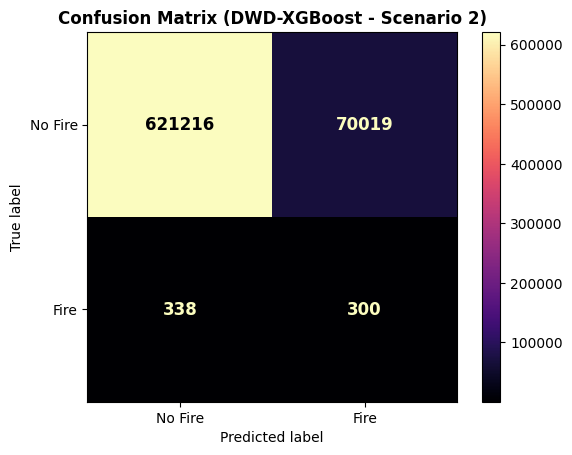

In [ ]:
# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fire', 'Fire'])
plt.figure(figsize=(8, 6))
disp.plot(cmap='magma', values_format='d')
for text in disp.text_.ravel():
    text.set_fontweight('bold')
    text.set_fontsize(12)
plt.title('Confusion Matrix (DWD-XGBoost - Scenario 2)', fontweight='bold')
plt.grid(False)
plt.show()


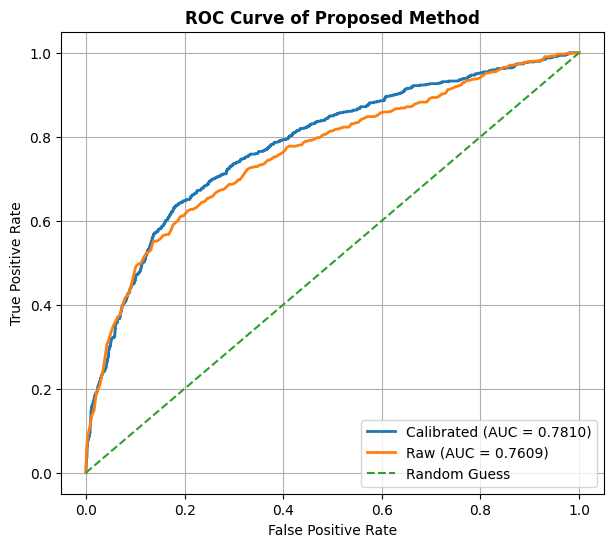

In [ ]:
# Plot ROC Curve based of the probabilities
def plot_roc_curve(true_y, y_prob):
    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
fpr_raw, tpr_raw, thresholds_raw = roc_curve(y_test, p_prob)
roc_auc_raw = auc(fpr_raw, tpr_raw)
# Plot
plt.figure(figsize=(7,6))
plot_roc_curve(y_test, y_prob)
plot_roc_curve(y_test, p_prob)
# diagonal line random classifier
plt.plot([0,1], [0,1], linestyle='--', label = f'Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Proposed Method", fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Plot Temporal Validation

In [ ]:
features_d = ['FF_mean', 'RH_mean', 'RR_sum', 'TAVG_mean', 'Aktivitas Manusia', 'longitude', 'latitude', 'Perhutanan', 'Perkebunan', 'Perladangan', 'Persemakan', 'year', 'month']
test_df = sumatra.iloc[valid_end:]
test_df = test_df[features_d]
test_df['fire_presence'] = y_test

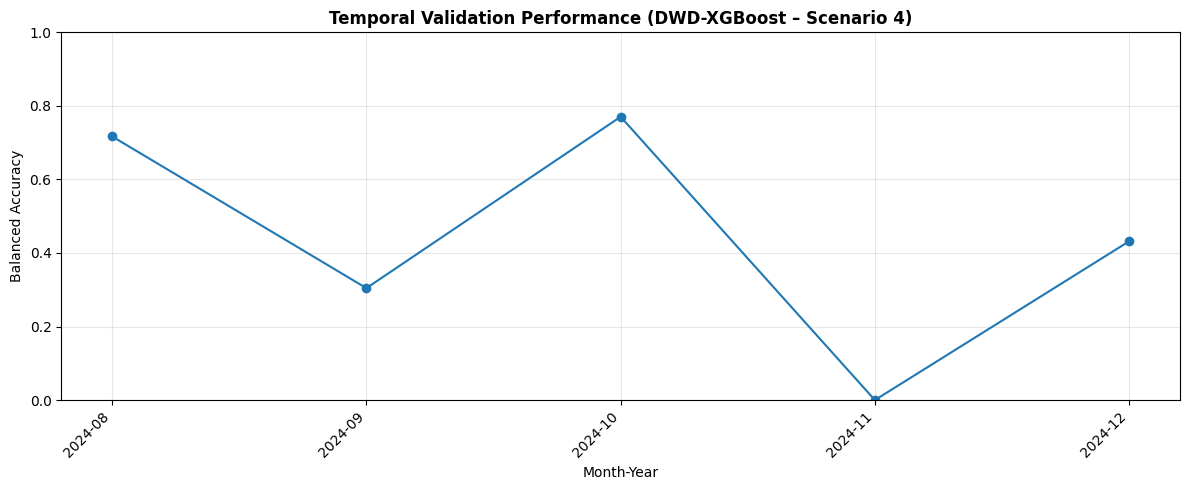

In [ ]:
monthly_bal_acc = test_df.groupby('month_year').apply(lambda x: balanced_accuracy_score(x['fire_presence'], x['prediction']))
# Plot
plt.figure(figsize=(12, 5))
x = np.arange(len(monthly_bal_acc))
plt.plot(x, monthly_bal_acc.values, marker='o')
plt.xticks(x, monthly_bal_acc.index.astype(str), rotation=45, ha='right')
plt.xlabel("Month-Year")
plt.ylabel("Balanced Accuracy")
plt.title("Temporal Validation Performance (DWD-XGBoost – Scenario 4)", fontweight='bold')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Plot Reliability Diagram

In [ ]:
# Generate Brier scores and probabilities for both raw and calibrated model
brier_score = brier_score_loss(y_test, y_prob)
brier_score_raw = brier_score_loss(y_test, p_prob)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
prob_true_raw, prob_pred_raw = calibration_curve(y_test, p_prob, n_bins=10)

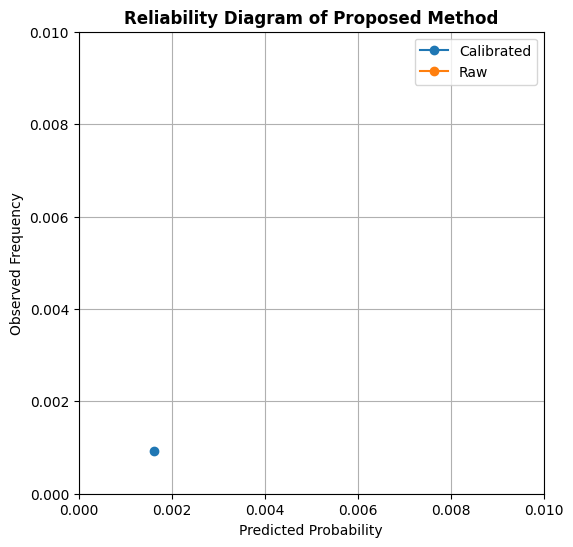

Exception ignored in: <function ResourceTracker.__del__ at 0x1032840e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1045c00e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(prob_pred,prob_true,marker='o',label='Calibrated')
plt.plot(prob_pred_raw,prob_true_raw,marker="o",label="Raw")
plt.plot([0,1],[0,1],linestyle='--',color='gray',label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.ylim([0,1])
plt.xlim([0,1])
plt.title("Reliability Diagram of Proposed Method", fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

## Spatial Plot

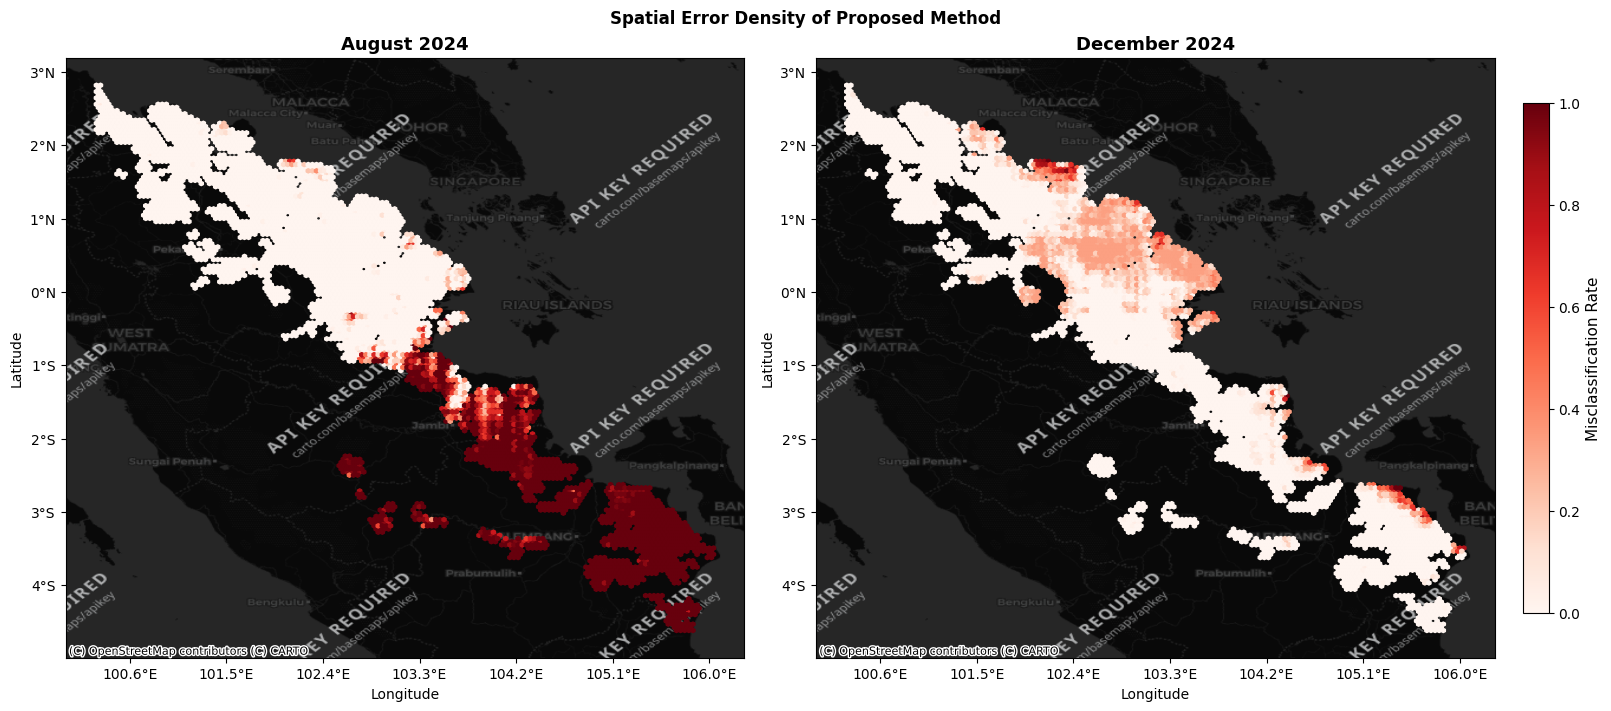

In [ ]:
# Correct prediction
correct = (y_test == y_pred)
# Create dataframe
spatial_df = test_df.copy()
spatial_df['correct'] = correct
# Misclassification
spatial_df['misclassified'] = (~correct).astype(int)
# Convert to datetime
spatial_df['date'] = pd.to_datetime(spatial_df['period_start'])
aug_df = spatial_df[spatial_df['date'].dt.month == 8].copy() # Dry season
dec_df = spatial_df[spatial_df['date'].dt.month == 12].copy() # Wet season
# Function to create GeoDataFrame
def create_geodf(df):
    geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
    return gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326').to_crs(epsg=3857)
gdf_aug = create_geodf(aug_df) # Dry season
gdf_dec = create_geodf(dec_df) # Wet season
# Coordinate transformer
transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
# Longitude formatter
def format_lon(x, pos):
    lon, lat = transformer.transform(x, 0)
    return f"{lon:.1f}°E"
# Latitude formatter
def format_lat(y, pos):
    lon, lat = transformer.transform(0, y)
    if lat >= 0:
        return f"{lat:.0f}°N"
    else:
        return f"{abs(lat):.0f}°S"

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
# Spatial error plot
def plot_spatial_error(ax, gdf, title):
    hb = ax.hexbin(gdf.geometry.x, gdf.geometry.y, C=gdf['misclassified'], gridsize=150, reduce_C_function=np.mean, cmap='Reds', vmin=0, vmax=1, mincnt=1)
    # Basemap
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatter)
    # Coordinate formatter
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_lon))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(format_lat))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    return hb
# Plot dry and wet season error densities
hb_aug = plot_spatial_error(axes[0], gdf_aug, "August 2024")
hb_dec = plot_spatial_error(axes[1], gdf_dec, "December 2024")
cbar = fig.colorbar(hb_aug, ax=axes, shrink=0.85, pad=0.02)
cbar.set_label("Misclassification Rate", fontsize=11)
plt.suptitle("Spatial Error Density of Proposed Method", fontweight='bold')
plt.show()

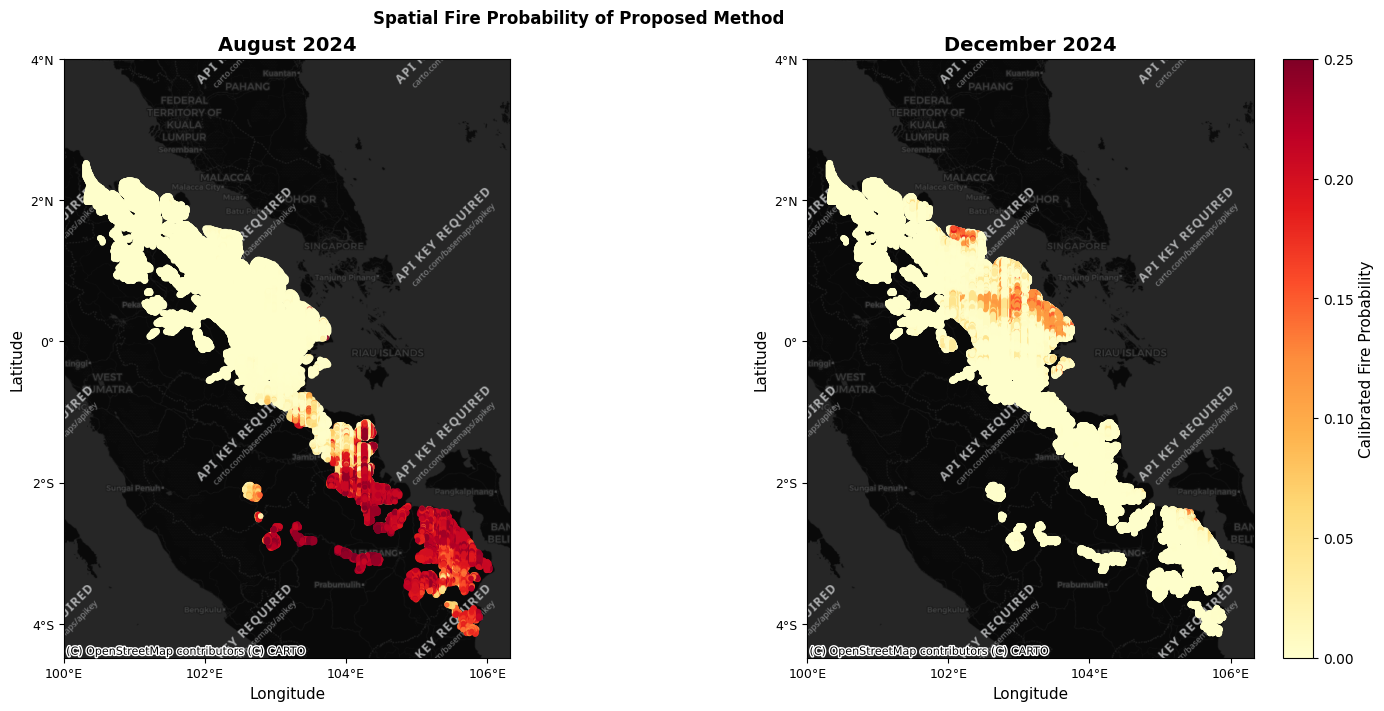

Exception ignored in: <function ResourceTracker.__del__ at 0x102bbc0e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x108aa00e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

In [ ]:
# Plot Fire Probability for calibrated model
y_prob = model_calibrated.predict_proba(X_test_scaled)[:, 1] # Generate fire probability
# Generate spatial dataframe
spatial_df = test_df.copy()
spatial_df["fire_probability"] = y_prob
# Convert date column to datetime
spatial_df["date"] = pd.to_datetime(spatial_df["period_start"])
# Split into dry and wet season
aug_df = spatial_df[spatial_df["date"].dt.month == 8].copy()
dec_df = spatial_df[spatial_df["date"].dt.month == 12].copy()
# Function to create GeoDataFrame
def create_geodf(df):
    geometry = [Point(lon, lat) for lon, lat in zip(df['longitude'], df['latitude'])]
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs='EPSG:4326')
    return gdf.to_crs(epsg=3857)
gdf_aug = create_geodf(aug_df)
gdf_dec = create_geodf(dec_df)
# Coordinate transformer
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
# Longitude range
lon_ticks = [100, 102, 104, 106]
# Latitude range
lat_ticks = [-4, -2, 0, 2, 4]
# Convert longitude and latitude to Web Mercator 
lon_x = [transformer.transform(lon, 0)[0] for lon in lon_ticks]
lat_y = [transformer.transform(0, lat)[1] for lat in lat_ticks]
# Plot fire probabilities for dry and wet seasons
fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
gdf_aug.plot(ax=axes[0],column="fire_probability",cmap="YlOrRd",markersize=8,alpha=0.8,vmin=0,vmax=0.25,legend=False)
ctx.add_basemap(axes[0],source=ctx.providers.CartoDB.DarkMatter)
gdf_dec.plot(ax=axes[1],column="fire_probability",cmap="YlOrRd",markersize=8,alpha=0.8,vmin=0,vmax=0.25,legend=False)
ctx.add_basemap(axes[1],source=ctx.providers.CartoDB.DarkMatter)
for ax in axes:
    # Longitude ticks
    ax.set_xticks(lon_x)
    # Latitude ticks
    ax.set_yticks(lat_y)
    # Longitude labels
    ax.set_xticklabels([f"{lon}°E" for lon in lon_ticks], fontsize=9)
    # Latitude labels
    ax.set_yticklabels(["0°" if lat == 0 else (f"{abs(lat)}°S" if lat < 0 else f"{lat}°N") for lat in lat_ticks], fontsize=9)
    ax.set_xlabel("Longitude", fontsize=11)
    ax.set_ylabel("Latitude", fontsize=11)
axes[0].set_title("August 2024", fontsize=14, fontweight="bold")
axes[1].set_title("December 2024", fontsize=14, fontweight="bold")
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=0, vmax=0.25))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.025, pad=0.02)
cbar.set_label("Calibrated Fire Probability", fontsize=11)
plt.suptitle("Spatial Fire Probability of Proposed Method", fontweight='bold')
plt.show()

#### Save to csv file

In [ ]:
# Save results 
spatial_df
spatial_df.to_csv("DWD-XGB-A Scenario 4", index=False)

## Frature Analysis

In [ ]:
# Generate test feature dataframe and series
test_feature_df = pd.DataFrame(X_test_scaled, columns=X_test_d.columns, index=test_df.index)
y_test_series = pd.Series(y_test, index=test_df.index)
test_feature_df["date"] = pd.to_datetime(test_df["period_start"])
# Split into dry and wet seasons
aug_mask = test_feature_df["date"].dt.month == 8
dec_mask = test_feature_df["date"].dt.month == 12
X_aug = test_feature_df.loc[aug_mask, X_test_d.columns]
y_aug = y_test_series.loc[aug_mask]
X_dec = test_feature_df.loc[dec_mask, X_test_d.columns]
y_dec = y_test_series.loc[dec_mask]

In [ ]:
# Use the raw best model
shap_model = best_model
# Background data
# Use a representative subset to reduce computational cost
background_aug = shap.sample(X_aug, 2000, random_state=209)
background_dec = shap.sample(X_dec, 2000, random_state=209)
# Model-agnostic SHAP explainer
explainer_aug = shap.Explainer(shap_model.predict_proba, background_aug, algorithm="permutation")
explainer_dec = shap.Explainer(shap_model.predict_proba, background_dec, algorithm="permutation")
# Calculate SHAP values
shap_exp_aug = explainer_aug(X_aug)
shap_exp_dec = explainer_dec(X_dec)
# Positive class = wildfire
shap_values_aug = shap_exp_aug.values[:, :, 1]
shap_values_dec = shap_exp_dec.values[:, :, 1]
# Mean absolute SHAP importance
shap_importance_aug = pd.DataFrame({
    "Feature": X_aug.columns,
    "SHAP_importance": np.abs(shap_values_aug).mean(axis=0)
}).sort_values(
    "SHAP_importance",
    ascending=False
)
shap_importance_dec = pd.DataFrame({
    "Feature": X_dec.columns,
    "SHAP_importance": np.abs(shap_values_dec).mean(axis=0)
}).sort_values(
    "SHAP_importance",
    ascending=False
)
print("August 2024")
print(shap_importance_aug)
print("December 2024")
print(shap_importance_dec)

Exception ignored in: <function ResourceTracker.__del__ at 0x104f380e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
PermutationExplainer explainer:   0%|          | 232/104434 [00:16<1:38:22, 17.65it/s]Exception ignored in: <function ResourceTracker.__del__ at 0x1058d00e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_trac

August 2024
             Feature  SHAP_importance
1            RH_mean         0.136498
0            FF_mean         0.060144
6         Perkebunan         0.037791
2             RR_sum         0.031798
5         Perhutanan         0.023816
4  Aktivitas Manusia         0.017652
3          TAVG_mean         0.017360
8         Persemakan         0.009127
7        Perladangan         0.002970


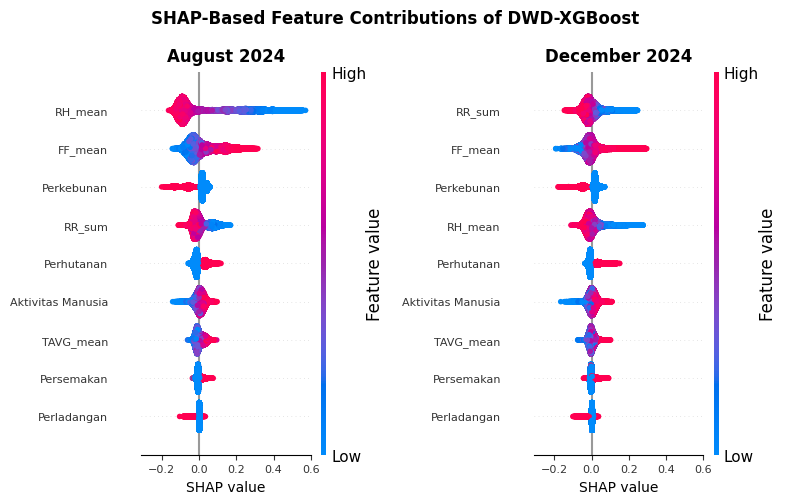

In [ ]:
# Plot SHAP importance for both dry and wet seasons
importance_aug = np.abs(shap_values_aug).mean(axis=0)
importance_dec = np.abs(shap_values_dec).mean(axis=0)
combined_importance = (importance_aug + importance_dec)/2
feature_order = np.argsort(combined_importance)[::-1]
# Top 15 features
feature_order = feature_order[:15]
# Set SHAP value limits
max_shap = max(np.abs(shap_values_aug[:, feature_order]).max(), np.abs(shap_values_dec[:, feature_order]).max())
min_shap = max(0, np.abs(shap_values_dec[:, feature_order]).max())
x_limit = max_shap * 1.05
x_min_limit = min_shap * 1.05
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(32, 8))
fig.suptitle("SHAP-Based Feature Contributions of DWD-XGBoost", fontsize=12, fontweight="bold", y=0.98)
axes[0].set_position([0.08, 0.12, 0.36, 0.75])
axes[1].set_position([0.52, 0.12, 0.36, 0.75])
plt.sca(axes[0])
shap.summary_plot(
    shap_values_aug[:, feature_order],
    X_aug.iloc[:, feature_order],
    feature_names=X_aug.columns[feature_order],
    plot_type="dot",
    max_display=10,
    show=False
)
axes[0].set_title("August 2024", fontsize=12, fontweight="bold", pad=8)
axes[0].set_xlim(-x_min_limit, x_limit)
axes[0].set_xlabel("SHAP value", fontsize=10)
axes[0].tick_params(axis="both", labelsize=8)
plt.sca(axes[1])
shap.summary_plot(
    shap_values_dec[:, feature_order],
    X_dec.iloc[:, feature_order],
    feature_names=X_dec.columns[feature_order],
    plot_type="dot",
    max_display=10,
    show=False
)
axes[1].set_title("December 2024", fontsize=12, fontweight="bold", pad=8)
axes[1].set_xlim(-x_min_limit, x_limit)
axes[1].set_xlabel("SHAP value", fontsize=10)
axes[1].tick_params(axis="both", labelsize=8)
plt.tight_layout()
plt.savefig("DWD_XGBoost_SHAP_August_December_2024_wide.png", dpi=600, bbox_inches="tight")
plt.show()

## Confidence Interval Analysis

### Bootstrap CI

In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = ((y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i + 1]))
        else:
            mask = ((y_prob >= bin_edges[i]) & (y_prob < bin_edges[i + 1]))
        if np.sum(mask) == 0:
            continue
        bin_accuracy = np.mean(y_true[mask])
        bin_confidence = np.mean(y_prob[mask])
        bin_fraction = np.sum(mask) / len(y_true)
        ece += bin_fraction * abs(bin_accuracy - bin_confidence)
    return ece

def calculate_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "PPR": np.mean(y_pred == 1),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "ECE": expected_calibration_error(y_true, y_prob, n_bins=10)
    }
    return metrics
# Function stratified bootstrap

def stratified_bootstrap_ci(y_true, y_prob, threshold=0.5, n_bootstrap=2000, confidence=0.95, random_state=209):
    """
    Stratified bootstrap confidence intervals.
    Resampling is performed independently within
    the wildfire and non-wildfire classes.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    rng = np.random.default_rng(random_state)
    # Separate classes
    idx_0 = np.where(y_true == 0)[0]
    idx_1 = np.where(y_true == 1)[0]
    bootstrap_results = []
    for b in range(n_bootstrap):
        # Resample each class independently
        boot_0 = rng.choice(idx_0, size=len(idx_0), replace=True)
        boot_1 = rng.choice(idx_1, size=len(idx_1), replace=True)
        boot_idx = np.concatenate([boot_0, boot_1])
        y_boot = y_true[boot_idx]
        p_boot = y_prob[boot_idx]
        metrics = calculate_metrics(y_boot, p_boot, threshold=threshold)
        bootstrap_results.append(metrics)

    bootstrap_df = pd.DataFrame(bootstrap_results)
    alpha = 1 - confidence
    lower_q = alpha / 2
    upper_q = 1 - alpha / 2
    results = []
    for metric in bootstrap_df.columns:
        point_estimate = calculate_metrics(y_true, y_prob, threshold=threshold)[metric]
        lower = bootstrap_df[metric].quantile(lower_q)
        upper = bootstrap_df[metric].quantile(upper_q)
        results.append({
            "Metric": metric,
            "Estimate": point_estimate,
            "CI Lower": lower,
            "CI Upper": upper
        })
    results_df = pd.DataFrame(results)
    return results_df, bootstrap_df

In [ ]:
ci_results, bootstrap_distribution = stratified_bootstrap_ci(y_true=y_test, y_prob=y_prob, threshold=best_threshold, n_bootstrap=2000, confidence=0.95, random_state=209)
print(ci_results)

Exception ignored in: <function ResourceTracker.__del__ at 0x1075740e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1029200e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

              Metric  Estimate  CI Lower  CI Upper
0  Balanced Accuracy  0.684462  0.665565  0.703881
1             Recall  0.470219  0.432602  0.509404
2                PPR  0.101636  0.100952  0.102371
3        Brier Score  0.002214  0.002193  0.002235
4                ECE  0.008403  0.008317  0.008485


## Bootstrap CI

### Hybrid Model and Baseline Model (XGBoost)

In [ ]:
# Function to perform paired stratified bootstrap
def paired_stratified_bootstrap(y_true, prob_xgb, prob_dwd_xgb, threshold_xgb, threshold_dwd_xgb, n_bootstrap=2000, random_state=209):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    prob_xgb = np.asarray(prob_xgb)
    prob_dwd_xgb = np.asarray(prob_dwd_xgb)
    # Stratify by true class
    idx_0 = np.where(y_true == 0)[0]
    idx_1 = np.where(y_true == 1)[0]
    differences = []
    for _ in range(n_bootstrap):
        # Same bootstrap observations are used
        # for both models
        boot_0 = rng.choice(idx_0, size=len(idx_0), replace=True)
        boot_1 = rng.choice(idx_1, size=len(idx_1), replace=True)
        boot_idx = np.concatenate([boot_0, boot_1])
        y_boot = y_true[boot_idx]
        p_xgb = prob_xgb[boot_idx]
        p_dwd = prob_dwd_xgb[boot_idx]
        metrics_xgb = calculate_metrics(y_boot, p_xgb, threshold=threshold_xgb)
        metrics_dwd = calculate_metrics(y_boot, p_dwd, threshold=threshold_dwd_xgb)
        differences.append({
            metric:
                metrics_xgb[metric] - metrics_dwd[metric]
            for metric in metrics_xgb
        })
    diff_df = pd.DataFrame(differences)
    results = []
    for metric in diff_df.columns:
        point_difference = (calculate_metrics(y_true, prob_xgb, threshold_xgb)[metric] - calculate_metrics(y_true, prob_dwd_xgb, threshold_dwd_xgb)[metric])
        results.append({
            "Metric": metric,
            "XGB - DWD-XGB": point_difference,
            "CI Lower": diff_df[metric].quantile(0.025),
            "CI Upper": diff_df[metric].quantile(0.975)
        })
    return pd.DataFrame(results)

In [ ]:
# Baseline model
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    max_delta_step=1,
    random_state=209,
    n_jobs=-1
)

In [ ]:
param_grid = {
    'max_depth': [4,6,8],
    'learning_rate': [0.05,0.1],
    'n_estimators': [100,200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

tscv = TimeSeriesSplit(
    n_splits=5
)

In [46]:
random_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

In [47]:
random_search.fit(
    X_train_scaled,
    y_train
)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=1.0; total time=   5.5s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=1.0; total time=  10.0s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=1.0; total time=  13.6s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=1.0; total time=  18.0s
[CV] END colsample_bytree=0.8, learning_rate=0.1, max_depth=4, n_estimators=100, subsample=1.0; total time=  20.2s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamm...
                                     max_cat_to_onehot=None, max_delta_step=1,
                                     max_depth=None, max_leaves=None,
                                     min_child_weight=None, missing=nan,
                                     monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=-1, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8], 'learning_rate': [0.1],
                         'max_depth': [4], 'n_estimators': [100],
                         'subsample': [1.0]},
             scoring='balanced_accuracy', verbose=2)

In [48]:
best_model_xgb = random_search.best_estimator_
model_calibrated_xgb = CalibratedClassifierCV(
    best_model_xgb,
    method='sigmoid',
    cv=5
)

model_calibrated_xgb.fit(X_train_scaled, y_train)
p_valid_cal_xgb = model_calibrated_xgb.predict_proba(X_valid_scaled)[:, 1]

In [49]:
thresholds = np.linspace(
    0.0,
    1.0,
    201
)
bal_acc_scores_xgb = []
for t in thresholds:
    y_valid_pred = (p_valid_cal_xgb >= t).astype(int)
    bal_acc = balanced_accuracy_score(
        y_valid,
        y_valid_pred
    )
    bal_acc_scores_xgb.append(bal_acc)
best_idx_xgb = np.argmax(bal_acc_scores_xgb)
best_threshold_xgb = thresholds[best_idx_xgb]

print("Best Threshold:")
print(best_threshold_xgb)

print("\nBest Balanced Accuracy:")
print(bal_acc_scores_xgb[best_idx_xgb])

Best Threshold:
0.005

Best Balanced Accuracy:
0.7099487608541288


In [ ]:
y_prob_xgb = model_calibrated_xgb.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_prob_xgb >= best_threshold_xgb).astype(int)

In [52]:
comparison_s2 = paired_stratified_bootstrap(
    y_true=y_test,

    prob_xgb=y_prob_xgb,
    prob_dwd_xgb=y_prob,
    threshold_xgb=best_threshold_xgb,
    threshold_dwd_xgb=best_threshold,
    n_bootstrap=2000,
    random_state=209
)

print(comparison_s2)

Exception ignored in: <function ResourceTracker.__del__ at 0x1071500e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1027740e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

              Metric  XGB - DWD-XGB  CI Lower  CI Upper
0  Balanced Accuracy       0.071463  0.054297  0.089099
1             Recall       0.199060  0.164577  0.235110
2                PPR       0.056266  0.055432  0.057105
3        Brier Score       0.005943  0.005874  0.006010
4                ECE       0.015142  0.014994  0.015287


### Hybrid Model and Basic DWD

In [ ]:
@dataclass
class GenDWD(ClassifierMixin, BaseEstimator):
    q: float = 1.0
    lambda2: float = 1e-2
    max_iter: int = 500
    tol: float = 1e-6
    verbose: bool = False
    random_state: int = 209
    coef_: np.ndarray = field(default=None, init=False)
    intercept_: float = field(default=None, init=False)
    fit_seconds_: float = field(default=None, init=False)
    optimizer_success_: bool = field(default=None, init=False)
    optimizer_message_: str = field(default=None, init=False)

    def _objective_grad(self, theta, X, y, sample_weight):
        b = theta[0]
        w = theta[1:]
        scores = X@w + b
        margins = y*scores
        weights = sample_weight/np.sum(sample_weight)
        losses = dwd_loss(margins,self.q)
        obj = (np.sum(weights*losses) + 0.5*self.lambda2*np.dot(w,w))
        dV = dwd_loss_derivative(margins,self.q)
        common = weights*dV*y
        grad_b = np.sum(common)
        grad_w = X.T@common + self.lambda2*w
        grad = np.r_[grad_b,grad_w]
        return obj,grad

    def fit(self,X,y,sample_weight=None):
        X=np.asarray(X,dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        y=ensure_pm_one(y)
        n,p=X.shape
        if sample_weight is None:
            sample_weight=np.ones(n)
        theta0=np.zeros(p+1)
        t0=time.perf_counter()
        res=minimize(fun=lambda th:self._objective_grad(th, X, y, sample_weight), x0=theta0, jac=True, method="L-BFGS-B", options=dict(maxiter=self.max_iter, ftol=self.tol, gtol=self.tol, disp=self.verbose))
        self.fit_seconds_=time.perf_counter()-t0
        self.optimizer_success_=res.success
        self.optimizer_message_=res.message
        self.intercept_=res.x[0]
        self.coef_=res.x[1:]
        return self

    def decision_function(self,X):
        X=np.asarray(X)
        return X@self.coef_+self.intercept_

    def predict(self,X):
        score=self.decision_function(X)
        return np.where(score>=0,1,0)

    def predict_proba(self,X):
        score=self.decision_function(X)
        p1=1/(1+np.exp(-score))
        return np.c_[1-p1,p1]

In [54]:
class GenDWDTransformer(TransformerMixin, BaseEstimator):
    def __init__(self,q=1.0,lambda2=1e-2,max_iter=500,tol=1e-6,verbose=False,random_state=209,projection="score"):
        self.q=q
        self.lambda2=lambda2
        self.max_iter=max_iter
        self.tol=tol
        self.verbose=verbose
        self.random_state=random_state
        self.projection=projection

    def fit(self,X,y):
        self.model_=GenDWD(q=self.q,lambda2=self.lambda2,max_iter=self.max_iter,tol=self.tol,verbose=self.verbose,random_state=self.random_state)
        self.model_.fit(X,y)
        return self

    def transform(self,X):
        X=np.asarray(X)
        if self.projection=="score":
            return self.model_.decision_function(X).reshape(-1,1)
        elif self.projection=="vector":
            return X@self.model_.coef_.reshape(-1,1)
        else:
            raise ValueError("projection must be 'score' or 'vector'")

    @property
    def coef_(self):
        return self.model_.coef_

    @property
    def intercept_(self):
        return self.model_.intercept_

In [55]:
dwd = GenDWD(
    q=1,
    lambda2=1e2,
    max_iter=500,
    tol=1e-6,
    verbose=False,
    random_state=209,
)

In [56]:
param_grid = {
    #'q': [0.5,1,1.5,2,4],
    #'q': [0.5],
    'lambda2':[1e-8,1e-4,1,1e4,1e8],
    #'lambda2':[1e-2]
}
tscv = TimeSeriesSplit(
    n_splits=5
)
grid_search_dwd = GridSearchCV(
    estimator=dwd,
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

In [57]:
grid_search_dwd.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn

[CV] END .....................................lambda2=0.0001; total time=   1.4s


/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn

[CV] END ......................................lambda2=1e-08; total time=   2.7s
[CV] END .....................................lambda2=0.0001; total time=   3.6s


...

/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power


[CV] END ................................lambda2=100000000.0; total time=   1.4s


/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:8: RuntimeWarning: divide by zero encountered in reciprocal
/var/folders/7p/pj3wx33d171dysy_vk0q_92w0000gn/T/ipykernel_1499/4143945933.py:18: RuntimeWarning: divide by zero encountered in power


[CV] END .....................................lambda2=0.0001; total time=  31.9s
[CV] END ................................lambda2=100000000.0; total time=   1.9s
[CV] END ................................lambda2=100000000.0; total time=   2.0s
[CV] END ....................................lambda2=10000.0; total time=  17.8s
[CV] END ..........................................lambda2=1; total time=  24.0s
[CV] END ......................................lambda2=1e-08; total time=  37.9s
[CV] END ....................................lambda2=10000.0; total time=  14.1s


GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=GenDWD(lambda2=100.0, q=1), n_jobs=-1,
             param_grid={'lambda2': [1e-08, 0.0001, 1, 10000.0, 100000000.0]},
             scoring='balanced_accuracy', verbose=2)

In [58]:
best_model_dwd = grid_search_dwd.best_estimator_
print("Best Parameters:")
print(grid_search_dwd.best_params_)
print("\nBest CV Score:")
print(grid_search_dwd.best_score_)

Best Parameters:
{'lambda2': 1e-08}

Best CV Score:
0.5141834141195354


In [59]:
model_calibrated_dwd = CalibratedClassifierCV(
    best_model_dwd,
    method='sigmoid',
    cv=5
)

model_calibrated_dwd.fit(X_train_scaled, y_train)
p_valid_cal_dwd = model_calibrated_dwd.predict_proba(X_valid_scaled)[:, 1]

In [60]:
thresholds = np.linspace(
    0.0,
    1.0,
    201
)
bal_acc_scores_dwd = []
for t in thresholds:

    y_valid_pred = (p_valid_cal_dwd>= t).astype(int)

    bal_acc = balanced_accuracy_score(
        y_valid,
        y_valid_pred
    )

    bal_acc_scores_dwd.append(bal_acc)

best_idx_dwd = np.argmax(bal_acc_scores_dwd)

best_threshold_dwd = thresholds[best_idx_dwd]

print("Best Threshold:", best_threshold_dwd)
print("Validation Balanced Accuracy:",
      bal_acc_scores_dwd[best_idx_dwd])

Best Threshold: 0.005
Validation Balanced Accuracy: 0.6617855029891822


In [61]:
y_prob_dwd = model_calibrated_dwd.predict_proba(
    X_test_scaled
)[:, 1]

In [ ]:
comparison_dwd = paired_stratified_bootstrap(
    y_true=y_test,
    prob_xgb=y_prob_dwd,
    prob_dwd_xgb=y_prob,
    threshold_xgb=best_threshold_dwd,
    threshold_dwd_xgb=best_threshold,
    n_bootstrap=2000,
    random_state=209
)

print(comparison_dwd)

Exception ignored in: <function ResourceTracker.__del__ at 0x104e4c0e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1040cc0e0>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/envs/sklearn-env/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Ex

              Metric  XGB - DWD-XGB  CI Lower  CI Upper
0  Balanced Accuracy       0.002204 -0.004163  0.008570
1             Recall       0.007837 -0.004702  0.020376
2                PPR       0.003433  0.003152  0.003697
3        Brier Score       0.000853  0.000824  0.000881
4                ECE       0.000704  0.000656  0.000748
